In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.colors import ListedColormap
import geopandas as gpd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## Daten laden
Als erstes Schritt reproduzieren wir die Ergebnisse des Papers Grecequet et al. (2019), Select but diverse countries are reducing both climate vulnerability and CO₂ emissions

In [10]:
vuln = pd.read_csv("data/vulnerability.csv")
edgar = pd.read_csv("data/EDGAR_GHG_per_capita.csv").rename(
    columns={"EDGAR Country Code": "ISO3", "Country": "Name"}
)

START, END = 1995, 2015

# Relative Veränderung
def relative_change(df, start, end):
    out = df[["ISO3", "Name", str(start), str(end)]].copy()
    out["rel_change"] = (out[str(end)] - out[str(start)]) / out[str(start)] * 100
    return out[["ISO3", "Name", "rel_change"]]

v_rel = relative_change(vuln, START, END).rename(
    columns={"rel_change": "vuln_rel_pct"}
)
e_rel = relative_change(edgar, START, END).rename(
    columns={"rel_change": "emi_rel_pct"}
)

# Merge für Gruppierung & Plot
df = v_rel.merge(e_rel, on=["ISO3", "Name"], how="inner").dropna()

# Gruppenzuweisung (Quadranten)
def assign_group(vuln_x, emi_y):
    if vuln_x < 0 and emi_y > 0:
        return "Group 1: Vulnerability↓, GHG↑"
    if vuln_x < 0 and emi_y < 0:
        return "Group 2: Vulnerability↓, GHG↓"
    if vuln_x > 0 and emi_y < 0:
        return "Group 3: Vulnerability↑, GHG↓"
    if vuln_x > 0 and emi_y > 0:
        return "Group 4: Vulnerability↑, GHG↑"
    return "On axis (0-change)"

df["group"] = [
    assign_group(x, y)
    for x, y in zip(df["vuln_rel_pct"], df["emi_rel_pct"])
]

# Scatterplot (wie im Paper)
fig = px.scatter(
    df,
    x="vuln_rel_pct",
    y="emi_rel_pct",
    color="group",
    hover_name="Name",
    hover_data={
        "ISO3": True,
        "group": True,
        "emi_rel_pct": ":.2f",
        "vuln_rel_pct": ":.2f",
    },
    labels={
        "vuln_rel_pct": "Relative change in climate vulnerability (%) (1995–2015)",
        "emi_rel_pct": "Relative change in GHG emissions per capita (%) (1995–2015)",
        "group": "Group"
    },
    title="Relative change (%) in climate vulnerability and GHG emissions (1995–2015)"
)

fig.add_vline(x=0)
fig.add_hline(y=0)
fig.show()

# Absolute Veränderungen (1995 minus 2015)
# Einzelwerte holen
v_abs = vuln[["ISO3", "1995", "2015"]].rename(
    columns={"1995": "vuln_1995", "2015": "vuln_2015"}
)
e_abs = edgar[["ISO3", "1995", "2015"]].rename(
    columns={"1995": "emi_1995", "2015": "emi_2015"}
)

# In df mergen
df = df.merge(v_abs, on="ISO3", how="left")
df = df.merge(e_abs, on="ISO3", how="left")

# Absolute Differenzen berechnen
df["vuln_diff_95_15"] = df["vuln_1995"] - df["vuln_2015"]
df["emi_diff_95_15"]  = df["emi_1995"]  - df["emi_2015"]

# Ausgabe (Beispiel: Group 2)
group2_95_15 = df[df["group"].str.startswith("Group 2")].copy()

group2_95_15 = group2_95_15.sort_values("vuln_rel_pct")

group2_95_15[[
    "ISO3",
    "Name",
    "vuln_rel_pct",
    "emi_rel_pct",
    "vuln_diff_95_15",
    "emi_diff_95_15"
]]

,ISO3,Name,vuln_rel_pct,emi_rel_pct,vuln_diff_95_15,emi_diff_95_15
142,UKR,Ukraine,-13.062776,-39.536433,0.054899,4.639528
35,CRI,Costa Rica,-12.630324,-3.432831,0.055427,0.107143
20,BWA,Botswana,-11.330722,-0.710875,0.056408,0.042773
102,NGA,Nigeria,-8.183811,-43.083070,0.043719,1.430477
79,LBN,Lebanon,-8.072126,-0.801694,0.035855,0.044773
76,KWT,Kuwait,-7.294468,-16.857198,0.028677,7.409027
133,TJK,Tajikistan,-7.084310,-6.479553,0.029474,0.123905
126,SVN,Slovenia,-7.011782,-9.709359,0.023961,0.978948
113,PRT,Portugal,-6.624624,-0.531409,0.024056,0.035311
50,FJI,Fiji,-6.596762,-10.418005,0.034819,0.330985


aut Plot haben wir die Länder identifiziert welche beides in Zeitraum von 1995 bis 2015 senken könnten. Wir geben eine Liste diesen Länder aus une werden nahand der Daten von 2015 bis 2023 untersuchen, ob die Länder auf Kurs geblieben sind. 
Gruppe 2 umfasst Länder, die zwischen 1995 und 2015 sowohl ihre Klimavulnerabilität als auch ihre GHG-Emissionen pro Kopf reduziert haben.

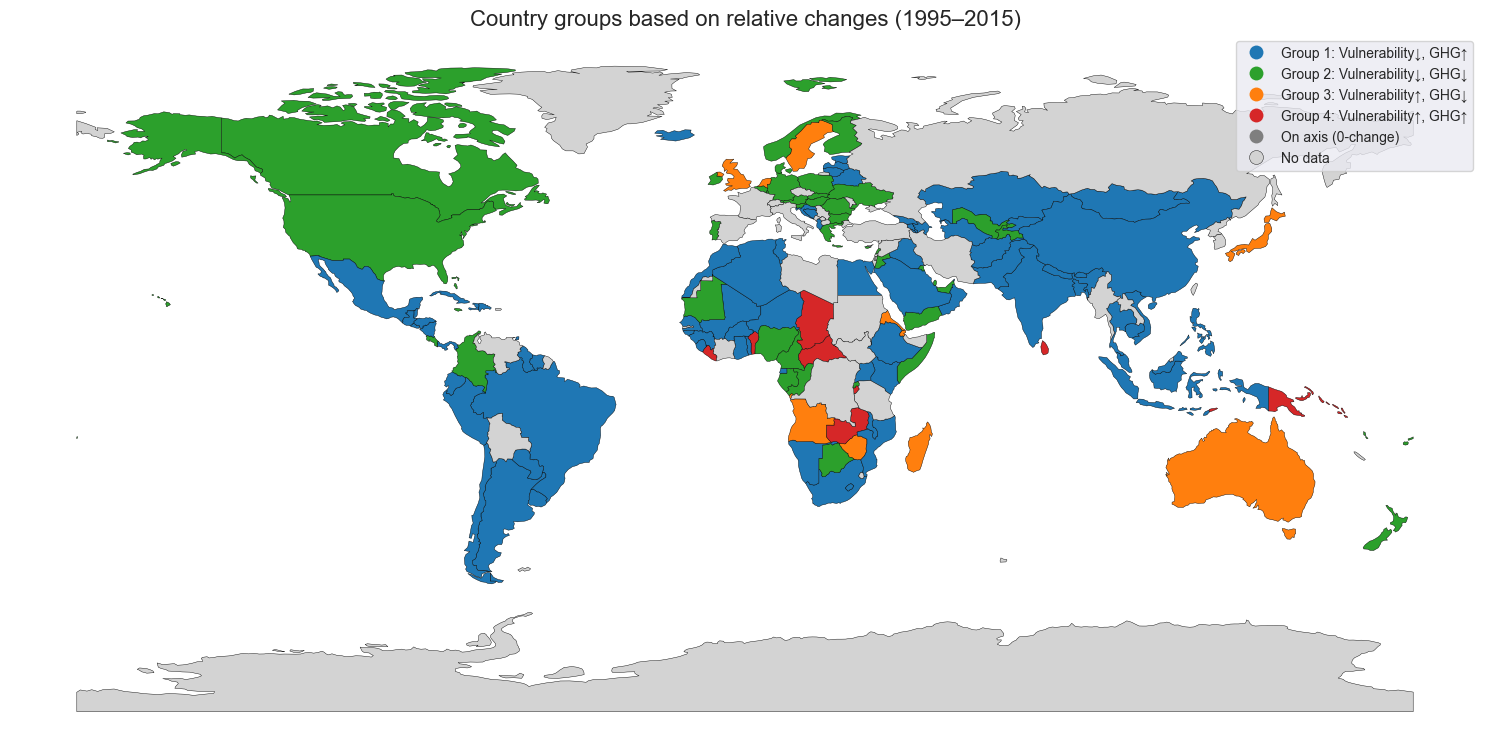

In [11]:
# Weltkarte laden (Natural Earth)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Natural Earth ISO Code mit bester Abdeckung
# (manchmal ist ISO_A3 leer/unklar, ISO_A3_EH ist robuster)
# Wir mergen Group-Zuweisung hinein
world_merged = world.merge(
    df[["ISO3", "group"]],
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)

# Für ein sauberes, stabiles Legend-Ordering: Kategorien setzen
group_order = [
    "Group 1: Vulnerability↓, GHG↑",
    "Group 2: Vulnerability↓, GHG↓",
    "Group 3: Vulnerability↑, GHG↓",
    "Group 4: Vulnerability↑, GHG↑",
    "On axis (0-change)"
]
world_merged["group"] = pd.Categorical(world_merged["group"], categories=group_order, ordered=True)

# Colormap (minimal, aber klar unterscheidbar)
# die Reihenfolge beibehalten; Farben sind absichtlich einfach.
cmap = ListedColormap(["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#7f7f7f"])

# ---- (E) Plot ----
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
world_merged.plot(
    column="group",
    ax=ax,
    legend=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title("Country groups based on relative changes (1995–2015)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# Group 2 (1995–2015) direkt aus dem Plot-DataFrame df
group2_95_15 = df[df["group"].str.startswith("Group 2")].copy()

print(f"Anzahl Group-2-Länder (1995–2015): {len(group2_95_15)}")

# minimal: sortieren nach Vulnerability-Veränderung (stärkste Verbesserung zuerst)
group2_95_15 = group2_95_15.sort_values("vuln_rel_pct")

# ausgeben
group2_95_15[["ISO3", "Name", "vuln_rel_pct", "emi_rel_pct"]]


Anzahl Group-2-Länder (1995–2015): 48


,ISO3,Name,vuln_rel_pct,emi_rel_pct
142,UKR,Ukraine,-13.062776,-39.536433
35,CRI,Costa Rica,-12.630324,-3.432831
20,BWA,Botswana,-11.330722,-0.710875
102,NGA,Nigeria,-8.183811,-43.083070
79,LBN,Lebanon,-8.072126,-0.801694
76,KWT,Kuwait,-7.294468,-16.857198
133,TJK,Tajikistan,-7.084310,-6.479553
126,SVN,Slovenia,-7.011782,-9.709359
113,PRT,Portugal,-6.624624,-0.531409
50,FJI,Fiji,-6.596762,-10.418005


Warum das Paper 42 Länder findet, wir aber 48 (trotz gleicher Logik)
Die Originalstudie berichtet 42 Länder, die zwischen 1995 und 2015 sowohl CO₂-Emissionen als auch Klimavulnerabilität reduzieren konnten. In unserer Reproduktion erhalten wir 48 Länder. Diese Abweichung ist erwartbar, da wir EDGAR GHG-Emissionen pro Kopf (CO₂-Äquivalente, inkl. CH₄ und N₂O) statt CO₂ aus fossilen Brennstoffen verwenden. Dadurch ändern sich die Systemgrenzen der Emissionen, und Länder können je nach Dominanz nicht-CO₂-Treibhausgase anders klassifiziert werden. Zusätzlich können Datenquellen- und Versionsunterschiede sowie Grenzfälle nahe 0% zu leicht abweichenden Gruppenzuordnungen führen. Die qualitative Aussage bleibt jedoch stabil: Eine selektive, aber diverse Gruppe von Ländern erreicht simultane Verbesserungen in beiden Dimensionen.

Jetzt untersuchen wir nur diese Länder weiter.
Definition „auf Kurs geblieben“:
Vulnerability weiter gesunken von 2015 → 2023
CO₂-Emissionen nicht gestiegen (≤ 0 % Veränderung)

Die zwischen 1995 und 2015 identifizierten Group-2-Länder wurden anschliessend für den Zeitraum 2015–2023 weiterverfolgt. Ein Land gilt als „on track“, wenn sowohl die Klimavulnerabilität weiter gesenkt als auch die Treibhausgasemissionen pro Kopf nicht erhöht wurden. Länder, bei denen mindestens eine dieser Bedingungen nicht erfüllt ist, werden als „off track“ klassifiziert.

In [13]:
# 48 Länder: sortieren (z.B. nach Vulnerability-Verbesserung)
g2 = group2_95_15.sort_values("vuln_rel_pct", ascending=False).copy()

# Erstelle Figure mit zwei Balken pro Land
fig = go.Figure()

# Vulnerability Balken (oben)
fig.add_trace(go.Bar(
    y=g2["Name"],
    x=g2["vuln_rel_pct"],
    name="Δ Vulnerability (%)",
    orientation='h',
    marker=dict(color='#d62728'),  # Rot für Vulnerability
    hovertemplate='<b>%{y}</b><br>' +
                  'Vulnerability: %{x:.2f}%<br>' +
                  '<extra></extra>'
))

# Emissions Balken (unten)
fig.add_trace(go.Bar(
    y=g2["Name"],
    x=g2["emi_rel_pct"],
    name="Δ GHG per capita (%)",
    orientation='h',
    marker=dict(color='#1f77b4'),  # Blau für Emissionen
    hovertemplate='<b>%{y}</b><br>' +
                  'Emissions: %{x:.2f}%<br>' +
                  '<extra></extra>'
))

# Layout anpassen
fig.update_layout(
    title="Group 2: Veränderung Klimavulnerabilität & GHG-Emissionen (1995–2015)",
    xaxis_title="Veränderung (%)",
    yaxis_title="",
    height=1200,
    barmode='group',  # Balken nebeneinander (nicht gestapelt)
    bargap=0.15,
    bargroupgap=0.1,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Nulllinie hinzufügen
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")

fig.show()

In [14]:
# 2015–2023 (relative change)
v_15_23 = relative_change(vuln, 2015, 2023).rename(
    columns={"rel_change": "vuln_rel_15_23"}
)
e_15_23 = relative_change(edgar, 2015, 2023).rename(
    columns={"rel_change": "emi_rel_15_23"}
)

df_15_23 = v_15_23.merge(
    e_15_23[["ISO3", "emi_rel_15_23"]],
    on="ISO3",
    how="inner"
).dropna()

# Absolute Werte 2015 und 2023 holen + Differenzen berechnen
v_abs_15_23 = vuln[["ISO3", "2015", "2023"]].rename(
    columns={"2015": "vuln_2015", "2023": "vuln_2023"}
)
e_abs_15_23 = edgar[["ISO3", "2015", "2023"]].rename(
    columns={"2015": "emi_2015", "2023": "emi_2023"}
)

abs_15_23 = v_abs_15_23.merge(e_abs_15_23, on="ISO3", how="inner")
abs_15_23["vuln_diff_15_23"] = abs_15_23["vuln_2015"] - abs_15_23["vuln_2023"]
abs_15_23["emi_diff_15_23"]  = abs_15_23["emi_2015"]  - abs_15_23["emi_2023"]

# Nur Group-2-Länder weiterverfolgen
track = group2_95_15.merge(
    df_15_23[["ISO3", "vuln_rel_15_23", "emi_rel_15_23"]],
    on="ISO3",
    how="left"
)

# Absolute Differenzen dazumergen
track = track.merge(
    abs_15_23[["ISO3", "vuln_diff_15_23", "emi_diff_15_23"]],
    on="ISO3",
    how="left"
)

# Klassifikation: auf Kurs vs. nicht auf Kurs
track["status_2015_2023"] = track.apply(
    lambda r: "on track"
    if (r["vuln_rel_15_23"] < 0 and r["emi_rel_15_23"] < 0)
    else "off track",
    axis=1
)

track = track.sort_values("status_2015_2023")

print(track["status_2015_2023"].value_counts())

track[[
    "ISO3",
    "Name",
    "vuln_rel_pct",
    "emi_rel_pct",
    "vuln_rel_15_23",
    "emi_rel_15_23",
    "vuln_diff_15_23",
    "emi_diff_15_23",
    "status_2015_2023"
]]

status_2015_2023
off track    26
on track     22
Name: count, dtype: int64


,ISO3,Name,vuln_rel_pct,emi_rel_pct,vuln_rel_15_23,emi_rel_15_23,vuln_diff_15_23,emi_diff_15_23,status_2015_2023
23,JAM,Jamaica,-4.117782,-29.700392,-2.092233,5.364891,0.009017,-0.157246,off track
21,SVK,Slovakia,-4.420636,-20.830805,0.893011,-8.374154,-0.003188,0.676323,off track
25,UZB,Uzbekistan,-3.796410,-10.104690,1.524511,9.808751,-0.005389,-0.548403,off track
26,LUX,Luxembourg,-3.787907,-26.204679,2.518719,-31.065459,-0.007649,5.643907,off track
28,NOR,Norway,-2.854062,-5.898013,0.308814,-18.168138,-0.000787,2.197476,off track
29,DEU,Germany,-2.818551,-19.037893,0.137542,-24.952393,-0.000414,2.761433,off track
30,POL,Poland,-2.498070,-18.476424,0.256197,-7.112990,-0.000781,0.721097,off track
20,NZL,New Zealand,-4.546728,-11.626861,0.447079,-15.485384,-0.001354,2.892000,off track
34,ATG,Antigua and Barbuda,-2.174285,-2.961457,-1.927328,6.886478,0.009191,-0.247620,off track
38,USA,United States,-2.012383,-19.428070,0.473628,-12.517388,-0.001471,2.489949,off track


Visualisierung der Länder die in der Gruppe 2 sind 

In [15]:
# Zählung
status_counts = track["status_2015_2023"].value_counts().reset_index()
status_counts.columns = ["status", "count"]

# Balkendiagramm
fig = px.bar(
    status_counts,
    x="status",
    y="count",
    text="count",
    labels={
        "status": "Status (2015–2023)",
        "count": "Number of countries"
    },
    title="Are Group-2 countries still on track after 2015?"
)

fig.update_traces(textposition="outside")
fig.update_layout(yaxis=dict(dtick=2))

fig.show()

Die Analyse zeigt, dass nicht alle Länder, die zwischen 1995 und 2015 simultane Verbesserungen erzielen konnten, diesen Pfad nach 2015 fortsetzen. Während ein Teil der Länder weiterhin sowohl sinkende Vulnerabilität als auch stabile oder sinkende Emissionen aufweist („on track“), ist bei anderen Ländern ein Rückfall in mindestens einer Dimension zu beobachten.

In [16]:
fig2 = px.scatter(
    track,
    x="vuln_rel_15_23",
    y="emi_rel_15_23",
    color="status_2015_2023",
    hover_name="Name",
    labels={
        "vuln_rel_15_23": "Relative change in climate vulnerability (%) (2015–2023)",
        "emi_rel_15_23": "Relative change in GHG emissions per capita (%) (2015–2023)",
        "status_2015_2023": "Status"
    },
    title="Post-2015 performance of Group-2 countries"
)

fig2.add_vline(x=0)
fig2.add_hline(y=0)

fig2.show()

Relative Veränderung 1995–2023 berechnen (minimal)

In [17]:
# Alle 48 Länder: gültige Werte behalten und nach stärkster Vulnerability-Verbesserung sortieren
all48 = track.dropna(subset=["vuln_rel_15_23"]).sort_values("vuln_rel_15_23").copy()

# Quadranten definieren (analog assign_group)
quadrants = {
    "Group 1: Vulnerability↓, GHG↑": (all48["vuln_rel_15_23"] < 0) & (all48["emi_rel_15_23"] > 0),
    "Group 2: Vulnerability↓, GHG↓": (all48["vuln_rel_15_23"] < 0) & (all48["emi_rel_15_23"] < 0),
    "Group 3: Vulnerability↑, GHG↓": (all48["vuln_rel_15_23"] > 0) & (all48["emi_rel_15_23"] < 0),
    "Group 4: Vulnerability↑, GHG↑": (all48["vuln_rel_15_23"] > 0) & (all48["emi_rel_15_23"] > 0)
}

# Für jeden Quadranten einen Plot erstellen
for group_name, group_filter in quadrants.items():
    group_data = all48[group_filter].sort_values("vuln_rel_15_23", ascending=False).copy()
    
    if len(group_data) == 0:
        print(f"Keine Länder in {group_name}")
        continue
    
    # Figure erstellen
    fig = go.Figure()
    
    # Vulnerability Balken
    fig.add_trace(go.Bar(
        y=group_data["Name"],
        x=group_data["vuln_rel_15_23"],
        name="Δ Vulnerability (%)",
        orientation='h',
        marker=dict(color='#d62728'),
        hovertemplate='<b>%{y}</b><br>' +
                      'Vulnerability: %{x:.2f}%<br>' +
                      'ISO3: %{customdata[0]}<br>' +
                      'Status: %{customdata[1]}<br>' +
                      '<extra></extra>',
        customdata=group_data[["ISO3", "status_2015_2023"]]
    ))
    
    # GHG Emissions Balken
    fig.add_trace(go.Bar(
        y=group_data["Name"],
        x=group_data["emi_rel_15_23"],
        name="Δ GHG per capita (%)",
        orientation='h',
        marker=dict(color='#1f77b4'),
        hovertemplate='<b>%{y}</b><br>' +
                      'Emissions: %{x:.2f}%<br>' +
                      'ISO3: %{customdata[0]}<br>' +
                      'Status: %{customdata[1]}<br>' +
                      '<extra></extra>',
        customdata=group_data[["ISO3", "status_2015_2023"]]
    ))
    
    # Layout
    n_countries = len(group_data)
    height = max(400, n_countries * 30 + 150)
    
    fig.update_layout(
        title=f"{group_name} (2015–2023)<br><sup>n={n_countries} Länder</sup>",
        xaxis_title="Veränderung (%)",
        yaxis_title="",
        height=height,
        barmode='group',
        bargap=0.15,
        bargroupgap=0.1,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Nulllinie
    fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")
    
    fig.show()

### GDP per capita – Daten und Verwendung

Für die ökonomische Einordnung der Länder wird das Bruttoinlandsprodukt pro Kopf (GDP per capita) verwendet. Die Daten stammen aus der Datei gdp_input.csv, welche länderspezifische GDP-pro-Kopf-Werte für mehrere Jahre enthält.

Zur Vergleichbarkeit wird für jedes Land ein fixes Referenzjahr (hier: 2015) gewählt. Dieser Wert wird anschliessend mit den zuvor identifizierten Ländern verknüpft (ISO3-Code) und dient zur Sortierung und Visualisierung nach wirtschaftlichem Entwicklungsstand.

Das GDP pro Kopf wird nicht zur Gruppenzuordnung verwendet, sondern ausschliesslich zur deskriptiven Analyse und zur Einordnung der Länder innerhalb der „on-track“-Gruppe.

In [18]:
# GDP laden
gdp = pd.read_csv("data/gdp_input.csv")  # anpassen falls Ordner anders heisst
# Beispiel: Spalten ["ISO3", "2015", "2016", ..., "2023"]

GDP_YEAR = "2015"  # oder "2020"/"2021", je nach dem was du verwenden willst

# Nur on-track Länder
on_track = track[track["status_2015_2023"] == "on track"].copy()

# GDP mergen
on_track = on_track.merge(
    gdp[["ISO3", GDP_YEAR]].rename(columns={GDP_YEAR: "gdp_pc"}),
    on="ISO3",
    how="left"
)

# nach GDP sortieren (absteigend)
on_track = on_track.sort_values("gdp_pc", ascending=False)

Die Grafik zeigt die 22 „on-track“-Länder, sortiert nach GDP pro Kopf in absteigender Reihenfolge. Sie verdeutlicht, dass nachhaltige Fortschritte in der gleichzeitigen Reduktion von Klimavulnerabilität und Emissionen nicht auf wohlhabende Staaten beschränkt sind, sondern über ein breites ökonomisches Spektrum hinweg auftreten.

In [19]:
fig = px.bar(
    on_track,
    x="Name",
    y="gdp_pc",
    text="gdp_pc",
    labels={
        "Name": "Country",
        "gdp_pc": f"GDP per capita ({GDP_YEAR})"
    },
    title="GDP per capita of on-track Group-2 countries (descending)"
)

fig.update_traces(
    texttemplate="%{text:.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title=f"GDP per capita ({GDP_YEAR})",
    xaxis_title="Country"
)

fig.show()


Zur vertieften Analyse werden Somalia und Vanuatu als Case Studies ausgewählt. Beide Länder gehören zu den einkommensschwächsten Staaten, konnten jedoch zwischen 1995 und 2015 sowohl ihre Klimavulnerabilität als auch ihre Emissionen pro Kopf senken und blieben auch nach 2015 auf Kurs. Trotz ähnlicher Ergebnisse unterscheiden sich die zugrunde liegenden Mechanismen deutlich.

In [23]:
# Weltkarte laden (Natural Earth)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# GDP-Daten der on-track Länder hinzufügen
world_merged = world.merge(
    on_track[["ISO3", "Name", "gdp_pc", "vuln_rel_pct", "emi_rel_pct", "vuln_rel_15_23", "emi_rel_15_23"]],
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)

# Interaktive Plotly Choropleth Map
fig = px.choropleth(
    world_merged,
    geojson=world_merged.geometry,
    locations=world_merged.index,
    color="gdp_pc",
    hover_name="Name",
    hover_data={
        "gdp_pc": ":.0f",
        "vuln_rel_pct": ":.2f",
        "emi_rel_pct": ":.2f",
        "vuln_rel_15_23": ":.2f",
        "emi_rel_15_23": ":.2f"
    },
    color_continuous_scale="YlGn",
    labels={
        "gdp_pc": f"GDP per capita ({GDP_YEAR})",
        "vuln_rel_pct": "Δ Vulnerability (%) 1995-2015",
        "emi_rel_pct": "Δ GHG (%) 1995-2015",
        "vuln_rel_15_23": "Δ Vulnerability (%) 2015-2023",
        "emi_rel_15_23": "Δ GHG (%) 2015-2023"
    },
    title=f"On-track Group-2 countries by GDP per capita (n={len(on_track)})"
)

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    coastlinecolor="Black",
    showland=True,
    landcolor="lightgrey",
    showocean=True,
    oceancolor="aliceblue"
)

fig.update_layout(
    height=600,
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

# Case Study: 4 Länder aus Gruppe 2 (2015-2023)

Diese Case Study untersucht vier ausgewählte Länder, die zwischen 2015 und 2023 sowohl ihre Klimavulnerabilität als auch ihre GHG-Emissionen pro Kopf reduziert haben:

- **Portugal**: Hochentwickeltes EU-Land mit gezielter grüner Transformation
- **Vanuatu**: Kleiner Inselstaat im Pazifik mit hoher Klimaexposition
- **Botswana**: Rohstoffabhängiges Land in Südafrika
- **Somalia**: Extrem armes, fragiles Land im Osten von Afrika

Diese Auswahl repräsentiert die **Heterogenität von Gruppe 2** – von hochentwickelt bis extrem arm, von diversifizierter bis limitierter Wirtschaft, von politisch intendiert bis strukturell bedingt.

## Teil 1: Zeitreihen-Analyse (2015-2023)

Die folgenden beiden Plots zeigen die **Entwicklung über die Zeit** für alle vier Länder:
- **GHG-Emissionen pro Kopf**: Zeigt die Emissionsentwicklung in Tonnen CO2-Äquivalenten
- **Klimavulnerabilität**: Zeigt die Entwicklung des ND-GAIN Vulnerability Scores

**Beobachtungen:**
- Alle vier Länder zeigen rückläufige Trends in beiden Indikatoren
- Die Ausgangswerte und das Ausmass der Reduktion variieren stark zwischen den Ländern
- Portugal und Somalia zeigen die stärksten relativen Verbesserungen

In [28]:
# Länderauswahl
COUNTRIES = {
    'PRT': 'Portugal',
    'VUT': 'Vanuatu',
    'BWA': 'Botswana',
    'SOM': 'Somalia'
}
# Farben für die Länder
COLORS = {
    'Portugal': '#1f77b4',    # Blau
    'Vanuatu': '#ff7f0e',     # Orange
    'Botswana': '#2ca02c',    # Grün
    'Somalia': '#d62728'      # Rot
}

# HILFSFUNKTIONEN
def extract_country_timeseries(vuln, edgar, iso3, start_year=2015, end_year=2023):
    """Extrahiert Zeitreihen für ein Land"""
    vuln_country = vuln[vuln["ISO3"] == iso3].copy()
    edgar_country = edgar[edgar["ISO3"] == iso3].copy()
    
    years = list(range(start_year, end_year + 1))
    year_cols = [str(y) for y in years]
    
    vuln_series = vuln_country[year_cols].values.flatten()
    ghg_series = edgar_country[year_cols].values.flatten()
    
    return {
        'years': years,
        'vulnerability': vuln_series,
        'ghg_per_capita': ghg_series,
        'name': vuln_country['Name'].values[0] if len(vuln_country) > 0 else iso3
    }

# TEIL 1A: GHG EMISSIONEN (ein Plot, alle 4 Länder)
fig_ghg = go.Figure()

for iso3, name in COUNTRIES.items():
    data = extract_country_timeseries(vuln, edgar, iso3)
    
    fig_ghg.add_trace(
        go.Scatter(
            x=data['years'],
            y=data['ghg_per_capita'],
            name=name,
            line=dict(color=COLORS[name], width=2.5),
            mode='lines+markers',
            marker=dict(size=6)
        )
    )

fig_ghg.update_layout(
    title={
        'text': 'GHG Emissionen pro Kopf (2015-2023)',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Jahr',
    yaxis_title='GHG pro Kopf (tCO2eq)',
    height=500,
    hovermode='x unified',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.98,
        xanchor="right",
        x=0.98
    ),
    template='plotly_white'
)

fig_ghg.show()

# TEIL 1B: VULNERABILITY (ein Plot, alle 4 Länder)
fig_vuln = go.Figure()

for iso3, name in COUNTRIES.items():
    data = extract_country_timeseries(vuln, edgar, iso3)
    
    fig_vuln.add_trace(
        go.Scatter(
            x=data['years'],
            y=data['vulnerability'],
            name=name,
            line=dict(color=COLORS[name], width=2.5),
            mode='lines+markers',
            marker=dict(size=6)
        )
    )

fig_vuln.update_layout(
    title={
        'text': 'Klimavulnerabilität (2015-2023)',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Jahr',
    yaxis_title='Vulnerability Score',
    height=500,
    hovermode='x unified',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.98,
        xanchor="right",
        x=0.98
    ),
    template='plotly_white'
)

fig_vuln.show()

## Teil 2: Quantitative Vergleichstabelle

Diese Tabelle fasst die **Ausgangswerte (2015), Endwerte (2023)** und **Veränderungen** (absolut und relativ) für alle vier Länder zusammen.

**Spalten-Erklärung:**
- `Vuln_2015/2023`: Vulnerability Score zu Beginn und Ende des Zeitraums
- `Vuln_Δ_abs`: Absolute Reduktion (2015 minus 2023, positiv = Verbesserung)
- `Vuln_Δ_%`: Relative Veränderung in Prozent (negativ = Reduktion)
- `GHG_2015/2023`: GHG pro Kopf zu Beginn und Ende
- `GHG_Δ_abs`: Absolute Reduktion
- `GHG_Δ_%`: Relative Veränderung in Prozent

**Interpretation:** Diese Zahlen bilden die quantitative Grundlage für die qualitative Analyse im nächsten Abschnitt.

In [29]:
# TEIL 2: QUANTITATIVE VERGLEICHSTABELLE
def create_comparison_table(vuln, edgar, countries_dict):
    """Erstellt quantitative Vergleichstabelle"""
    rows = []
    
    for iso3, name in countries_dict.items():
        data = extract_country_timeseries(vuln, edgar, iso3)
        
        vuln_2015 = data['vulnerability'][0]
        ghg_2015 = data['ghg_per_capita'][0]
        vuln_2023 = data['vulnerability'][-1]
        ghg_2023 = data['ghg_per_capita'][-1]
        
        vuln_diff = vuln_2015 - vuln_2023
        ghg_diff = ghg_2015 - ghg_2023
        
        vuln_rel_pct = ((vuln_2023 - vuln_2015) / vuln_2015) * 100
        ghg_rel_pct = ((ghg_2023 - ghg_2015) / ghg_2015) * 100
        
        rows.append({
            'ISO3': iso3,
            'Country': name,
            'Vuln_2015': round(vuln_2015, 4),
            'Vuln_2023': round(vuln_2023, 4),
            'Vuln_Δ_abs': round(vuln_diff, 4),
            'Vuln_Δ_%': round(vuln_rel_pct, 2),
            'GHG_2015': round(ghg_2015, 2),
            'GHG_2023': round(ghg_2023, 2),
            'GHG_Δ_abs': round(ghg_diff, 2),
            'GHG_Δ_%': round(ghg_rel_pct, 2)
        })
    
    return pd.DataFrame(rows)

comparison_df = create_comparison_table(vuln, edgar, COUNTRIES)
comparison_df

,ISO3,Country,Vuln_2015,Vuln_2023,Vuln_Δ_abs,Vuln_Δ_%,GHG_2015,GHG_2023,GHG_Δ_abs,GHG_Δ_%
0,PRT,Portugal,0.3391,0.3185,0.0206,-6.07,6.61,5.44,1.17,-17.76
1,VUT,Vanuatu,0.5964,0.5631,0.0334,-5.59,2.40,2.00,0.41,-16.89
2,BWA,Botswana,0.4414,0.4324,0.0090,-2.04,5.97,4.97,1.00,-16.78
3,SOM,Somalia,0.6152,0.6105,0.0047,-0.76,2.26,1.95,0.32,-13.96


## Teil 3: Zusammenfassende Visualisierung

Diese Bar-Charts visualisieren die **relativen Veränderungen** für Vulnerability und GHG-Emissionen im direkten Vergleich.

**Wichtige Erkenntnisse:**
- Negative Werte bedeuten **Reduktion** (= Verbesserung)
- Die Länder zeigen sehr unterschiedliche Ausmasse der Reduktion
- Sowohl bei Vulnerability als auch bei GHG gibt es deutliche Unterschiede zwischen den vier Ländern

Diese Visualisierung ermöglicht einen schnellen Vergleich der **quantitativen Performance** aller vier Case Studies.

In [31]:
# TEIL 3: ZUSAMMENFASSENDE VISUALISIERUNG
fig_summary = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Vulnerability Reduktion (%)', 'GHG Reduktion (%)'],
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

# Vulnerability
fig_summary.add_trace(
    go.Bar(
        x=comparison_df['Country'],
        y=comparison_df['Vuln_Δ_%'],
        name='Vulnerability Δ%',
        marker_color='#d62728',
        text=comparison_df['Vuln_Δ_%'].round(1),
        textposition='outside'
    ),
    row=1, col=1
)

# GHG
fig_summary.add_trace(
    go.Bar(
        x=comparison_df['Country'],
        y=comparison_df['GHG_Δ_%'],
        name='GHG Δ%',
        marker_color='#1f77b4',
        text=comparison_df['GHG_Δ_%'].round(1),
        textposition='outside'
    ),
    row=1, col=2
)

fig_summary.update_xaxes(title_text="Country", row=1, col=1)
fig_summary.update_xaxes(title_text="Country", row=1, col=2)
fig_summary.update_yaxes(title_text="Veränderung (%)", row=1, col=1)
fig_summary.update_yaxes(title_text="Veränderung (%)", row=1, col=2)

fig_summary.update_layout(
    height=500,
    title_text="Vergleich: Relative Veränderungen 2015-2023",
    title_x=0.5,
    showlegend=False
)

fig_summary.show()

## Teil 4: Qualitative Vergleichstabelle

Diese Tabelle ergänzt die quantitativen Daten um **kontextuelle und qualitative Faktoren**, die für das Verständnis der unterschiedlichen Pfade entscheidend sind.

**Dimensionen der Analyse:**
1. **Strukturelle Faktoren**: Einkommensniveau, Region, Bevölkerung, Wirtschaftsstruktur
2. **Klimakontext**: Exposition gegenüber Klimarisiken
3. **Mechanismen**: Haupttreiber für die Reduktion von GHG und Vulnerability
4. **Governance**: Rolle internationaler Akteure
5. **Bewertung**: Charakter des Erfolgs und Nachhaltigkeit der Fortschritte

**Zweck:** Diese Tabelle bildet die Grundlage für die detaillierte qualitative Analyse der vier Länder und ermöglicht es, die unterschiedlichen **Erfolgstypen** zu identifizieren und zu vergleichen.

In [32]:
# TEIL 4: QUALITATIVE VERGLEICHSTABELLE
qual_data = {
    'Aspekt': [
        'Einkommensniveau',
        'Region',
        'Bevölkerung (ca.)',
        'Wirtschaftsstruktur',
        'Klimaexposition',
        'Haupttreiber GHG↓',
        'Haupttreiber Vuln↓',
        'Rolle int. Akteure',
        'Charakter des Erfolgs',
        'Nachhaltigkeit'
    ],
    'Portugal': [
        'Hochentwickelt',
        'EU/Südeuropa',
        '~10 Mio',
        'Diversifiziert',
        'Mittel (Dürre, Waldbrände)',
        'Erneuerbare Energien, Kohleausstieg',
        'EU-Klimapolitik, Anpassungsstrategie',
        'Mittel (EU-Rahmen)',
        'Politisch intendiert',
        'Robust'
    ],
    'Vanuatu': [
        'Niedrig-Mittel',
        'Pazifik',
        '~320k',
        'Klein, begrenzt (Tourismus, Landwirtschaft)',
        'Sehr hoch (Zyklone, Meeresspiegelanstieg)',
        'Niedrige Basis, Erneuerbare',
        'Gezielte Adaptation, Frühwarnsysteme',
        'Wichtig (Klimafinanzierung)',
        'Politisch intendiert',
        'Vergleichsweise robust'
    ],
    'Botswana': [
        'Oberes Mittel',
        'Southern Africa',
        '~2.6 Mio',
        'Diamanten-dominiert, Diversifizierung läuft',
        'Mittel-hoch (Dürre)',
        'Effizienzsteigerung, strukturell',
        'Wirtschaftliche Stabilität, Entwicklung',
        'Begrenzt',
        'Gemischt (strukturell + gezielt)',
        'Verletzlich (Rohstoffpreise)'
    ],
    'Somalia': [
        'Sehr niedrig (LDC)',
        'Horn of Africa',
        '~18 Mio',
        'Sehr limitiert (Landwirtschaft, Viehzucht)',
        'Hoch (Dürre, Konflikte)',
        'Unterentwicklung (kaum Industrie)',
        'Humanitäre Hilfe, Basisentwicklung',
        'Dominant',
        'Unbeabsichtigter Nebeneffekt',
        'Sehr fragil'
    ]
}

qual_df = pd.DataFrame(qual_data)
qual_df

,Aspekt,Portugal,Vanuatu,Botswana,Somalia
0,Einkommensniveau,Hochentwickelt,Niedrig-Mittel,Oberes Mittel,Sehr niedrig (LDC)
1,Region,EU/Südeuropa,Pazifik,Southern Africa,Horn of Africa
2,Bevölkerung (ca.),~10 Mio,~320k,~2.6 Mio,~18 Mio
3,Wirtschaftsstruktur,Diversifiziert,"Klein, begrenzt (Tourismus, Landwirtschaft)","Diamanten-dominiert, Diversifizierung läuft","Sehr limitiert (Landwirtschaft, Viehzucht)"
4,Klimaexposition,"Mittel (Dürre, Waldbrände)","Sehr hoch (Zyklone, Meeresspiegelanstieg)",Mittel-hoch (Dürre),"Hoch (Dürre, Konflikte)"
5,Haupttreiber GHG↓,"Erneuerbare Energien, Kohleausstieg","Niedrige Basis, Erneuerbare","Effizienzsteigerung, strukturell",Unterentwicklung (kaum Industrie)
6,Haupttreiber Vuln↓,"EU-Klimapolitik, Anpassungsstrategie","Gezielte Adaptation, Frühwarnsysteme","Wirtschaftliche Stabilität, Entwicklung","Humanitäre Hilfe, Basisentwicklung"
7,Rolle int. Akteure,Mittel (EU-Rahmen),Wichtig (Klimafinanzierung),Begrenzt,Dominant
8,Charakter des Erfolgs,Politisch intendiert,Politisch intendiert,Gemischt (strukturell + gezielt),Unbeabsichtigter Nebeneffekt
9,Nachhaltigkeit,Robust,Vergleichsweise robust,Verletzlich (Rohstoffpreise),Sehr fragil


## Teil 5: Detaillierte qualitative Länderanalysen

### 5.1 Portugal – EU-Vorreiter bei grüner Transformation

**Emissionen pro Kopf ↓**

**Haupttreiber:**
- Massiver Ausbau erneuerbarer Energien (Solar, Wind, Wasserkraft)
- Kohleausstieg bis 2021 – letzte Kohlekraftwerke geschlossen
- Effizienzsteigerungen im Verkehrs- und Gebäudesektor
- EU-Emissionshandelssystem (ETS) als regulatorischer Rahmen
- Investitionen in Elektromobilität und öffentlichen Nahverkehr

**Vulnerability ↓**

**Haupttreiber:**
- Nationale Anpassungsstrategie (ENAAC – Estratégia Nacional de Adaptação às Alterações Climáticas)
- Verbessertes Waldbrand-Management und Frühwarnsysteme
- Wassermanagement-Strategien bei zunehmender Dürre
- EU-Fördermittel für Klimaanpassung (LIFE-Programm, Kohäsionsfonds)
- Modernisierung der Landwirtschaft mit klimaresilienten Praktiken

**Einordnung**

Portugal ist ein klassischer Fall **politisch intendierter Transformation**. Der EU-Rahmen spielt eine wichtige Rolle durch Zielvorgaben, Finanzierung und Regulierung. Die Fortschritte sind **nachhaltig und robust**, da sie auf langfristigen politischen Commitments und strukturellen Veränderungen im Energiesektor basieren. Portugal zeigt: Dekarbonisierung und Vulnerabilitätsreduktion sind mit wirtschaftlichem Wachstum vereinbar.

---

### 5.2 Vanuatu – Anpassung unter hoher Exposition

**Emissionen pro Kopf ↓**

**Haupttreiber:**
- Sehr niedrige Emissionen aufgrund kleiner Bevölkerung (~320.000)
- Fehlende Industrie und geringe Ausgangsbasis
- Zunehmender Einsatz erneuerbarer Energien (v.a. Solar und Kleinwasserkraft für Stromerzeugung)
- Emissionspfad bleibt stabil trotz wachsender Entwicklungsbedarfe
- Fokus auf nachhaltige Tourismusentwicklung

**Vulnerability ↓**

**Haupttreiber:**
- Aktive und gezielte Anpassungsmaßnahmen:
  - Katastrophenvorsorge (Cyclone preparedness)
  - Frühwarnsysteme für Extremwetter
  - Community-basierte Resilienzstrategien
- Starke Rolle internationaler Klimafinanzierung (Green Climate Fund, Weltbank, Pacific Islands Forum)
- Küstenschutzmassnahmen und Anpassung der Infrastruktur
- Nationale Anpassungspläne (NAPA) mit klaren Prioritäten

**Einordnung**

Vanuatu zeigt, dass **Vulnerabilität reduzierbar ist, auch bei sehr hoher physischer Klimaexposition**. Als kleiner Inselstaat mit extremem Risiko durch Zyklone und Meeresspiegelanstieg beweist Vanuatu, dass Anpassungspolitik selbst bei begrenzten Ressourcen wirksam sein kann. Die internationale Unterstützung ist wichtig, aber **eingebettet in lokale Strukturen und politischen Willen**. Fortschritte sind **vergleichsweise robust**, bleiben aber abhängig von kontinuierlicher Finanzierung.

---

### 5.3 Botswana – Rohstoff-Ökonomie im Wandel

**Emissionen pro Kopf ↓**

**Haupttreiber:**
- Effizienzsteigerungen im Energiesektor (hauptsächlich kohlebasiert)
- Strukturelle Faktoren: Diamantenabbau bleibt energieintensiv, aber Sektor relativ stabil
- Erste Schritte in Richtung Diversifizierung (Tourismus, Dienstleistungen)
- Ausbau von Solar-Projekten (z.B. Photovoltaik-Anlagen in Phakalane, Selebi-Phikwe)
- Reduktion von Gas-Flaring im Bergbausektor

**Vulnerability ↓**

**Haupttreiber:**
- Wirtschaftliche Stabilität durch Rohstoffreichtum (Diamanten)
- Kontinuierliche Investitionen in Gesundheit und Bildung
- Wassermanagement in semi-arider Region (North-South Carrier Projekt)
- Good Governance und politische Stabilität (im afrikanischen Vergleich)
- Infrastrukturausbau in ländlichen Gebieten

**Einordnung**

Botswana zeigt einen **gemischten Erfolg**: teils strukturell bedingt, teils gezielt gesteuert. Die wirtschaftliche Stabilität durch Diamantenexporte schafft fiskalischen Spielraum für Entwicklungsinvestitionen. Die Fortschritte sind jedoch **verletzlich** gegenüber Rohstoffpreisschwankungen und globalen Diamantenmärkten. Die Herausforderung besteht darin, die Diversifizierung voranzutreiben, um langfristig unabhängiger von Rohstoffexporten zu werden.

---

### 5.4 Somalia – Fortschritte unter Fragilität

**Emissionen pro Kopf ↓**

**Haupttreiber:**
- Sehr niedriger Ausgangswert durch:
  - Kaum Industrialisierung
  - Sehr geringer Stromverbrauch pro Kopf
- Keine emissionsintensiven Sektoren (z.B. Schwerindustrie)
- Wirtschaftsstruktur basiert auf Landwirtschaft und Viehzucht
- Emissionsreduktion ist **strukturell bedingt**, nicht politisch gesteuert
- Fehlende wirtschaftliche Entwicklung hält Emissionen niedrig

**Vulnerability ↓**

**Haupttreiber:**
- Verbesserungen trotz fragiler Staatlichkeit, v.a. durch:
  - Internationale humanitäre Hilfe (Gesundheit, Ernährung, Wasser – WASH-Programme)
  - Punktuelle Stabilisierung in Basisdiensten
  - UN-Interventionen und NGO-Programme
- Reduktion der Vulnerabilität **nicht durch Klimapolitik im engeren Sinn**, sondern durch Grundlagen der menschlichen Entwicklung
- Verbesserungen in Ernährungssicherheit und Gesundheitsversorgung

**Einordnung**

Fortschritte sind **verletzlich und stark von externer Unterstützung abhängig**. Dennoch empirisch relevant: Simultane Verbesserung ist **selbst unter extremen Bedingungen möglich**. Somalia zeigt jedoch auch die Grenzen: Ohne eigene staatliche Kapazität und bei anhaltenden Konflikten bleiben Fortschritte **sehr fragil**. Der "Erfolg" ist ein **unbeabsichtigter Nebeneffekt** von Unterentwicklung (niedrige Emissionen) und humanitärer Intervention (Vulnerabilitätsreduktion), nicht das Ergebnis gezielter Klimapolitik.

---

### 5.5 Vergleichende Übersicht: Alle vier Länder

| Aspekt | Portugal | Vanuatu | Botswana | Somalia |
|--------|----------|---------|----------|---------|
| **Einkommensniveau** | Hochentwickelt | Niedrig-Mittel | Oberes Mittel | Sehr niedrig (LDC) |
| **Staatliche Kapazität** | Hoch | Begrenzt, aber stabil | Mittel, stabil | Sehr gering / fragil |
| **Klimaexposition** | Mittel (Dürre, Waldbrände) | Sehr hoch (Zyklone, Meeresspiegelanstieg) | Mittel-hoch (Dürre) | Hoch (Dürre, Konflikte) |
| **Wirtschaftsstruktur** | Diversifiziert | Klein, begrenzt | Diamanten-dominiert, Diversifizierung läuft | Sehr limitiert |
| **Emissionsstruktur** | Mittel, sinkend | Sehr niedrig, stabil | Mittel, kohlebasiert | Extrem niedrig |
| **Haupttreiber Emissionsrückgang** | Erneuerbare Energien, Kohleausstieg | Niedriger Ausgangswert + Erneuerbare | Effizienzsteigerung, erste Solar-Projekte | Strukturelle Unterentwicklung |
| **Haupttreiber Vulnerabilitätsrückgang** | EU-Klimapolitik, Anpassungsstrategie | Gezielte Anpassungspolitik, Frühwarnsysteme | Wirtschaftliche Stabilität, Good Governance | Humanitäre Hilfe, Basisentwicklung |
| **Rolle internationaler Akteure** | Mittel (EU-Rahmen) | Wichtig (Klimafinanzierung) | Begrenzt | Dominant |
| **Charakter des Erfolgs** | Politisch intendiert | Politisch intendiert | Gemischt (strukturell + gezielt) | Unbeabsichtigter Nebeneffekt |
| **Nachhaltigkeit der Fortschritte** | Robust | Vergleichsweise robust | Verletzlich (Rohstoffpreise) | Sehr fragil |
| **Replizierbarkeit** | Hoch (mit entsprechenden Ressourcen) | Mittel (hohe Abhängigkeit von ext. Finanzierung) | Mittel (Rohstoffreichtum als Voraussetzung) | Niedrig (extreme Fragilität) |

---

### 5.6 Synthese: Unterschiedliche Pfade zu Gruppe 2

Die vier Länder zeigen, dass **simultane Reduktionen von Klimavulnerabilität und Emissionen auf sehr unterschiedlichen Wegen erreicht werden**:

**Cluster A: Politisch intendierte Transformation**
- **Portugal** und **Vanuatu** verfolgen bewusste Klimastrategien
- Gezielte Investitionen in Mitigation und Adaptation
- Unterschiede in Ressourcenverfügbarkeit und Exposition, aber gemeinsames Merkmal: **politischer Wille**
- Fortschritte sind **vergleichsweise nachhaltig**

**Cluster B: Strukturell getriebene Fortschritte**
- **Botswana** und **Somalia** profitieren primär von strukturellen Faktoren
- Fortschritte sind **nicht gezielt durch Klimapolitik** herbeigeführt
- Unterschiede: Botswana hat fiskalischen Spielraum durch Rohstoffe; Somalia ist abhängig von humanitärer Hilfe
- Fortschritte sind **fragiler und verletzlicher**

**Zentrale Erkenntnisse:**

1. **Kein einheitlicher Pfad**: „On track" zu sein bedeutet nicht, dass alle Länder denselben Weg gehen. Die Mechanismen unterscheiden sich fundamental.

2. **Intentionalität erhöht Robustheit**: Politisch gesteuerte Fortschritte (Portugal, Vanuatu) sind nachhaltiger als strukturell bedingte (Somalia, Botswana).

3. **Einkommensniveau ≠ Erfolg**: Sowohl hochentwickelte (Portugal) als auch sehr arme Länder (Somalia) können in Gruppe 2 sein – aber aus sehr unterschiedlichen Gründen.

4. **Externe Unterstützung ist wichtig, aber nicht hinreichend**: Vanuatu zeigt, dass internationale Klimafinanzierung wirksam sein kann, wenn sie in lokale Strukturen eingebettet ist. Somalia zeigt, dass humanitäre Hilfe allein keine robusten Fortschritte garantiert.

5. **Wirtschaftliche Diversifizierung ist kein Muss, aber hilfreich**: Somalia ist trotz sehr limitierter Wirtschaftsstruktur in Gruppe 2. Allerdings ermöglicht Diversifizierung (Portugal, Botswana) nachhaltigere Transformationspfade.

6. **Klimaexposition ≠ Vulnerabilität**: Vanuatu hat extrem hohe Exposition, reduziert aber Vulnerabilität durch gezielte Anpassung. Somalia hat hohe Exposition und hohe Vulnerabilität, Verbesserungen sind primär durch Basisentwicklung getrieben.

Die Heterogenität von Gruppe 2 unterstreicht: **Klimapolitik muss kontextspezifisch sein**. Was in Portugal funktioniert, lässt sich nicht direkt auf Somalia übertragen. Gleichzeitig zeigt die Analyse, dass selbst unter extremsten Bedingungen simultane Fortschritte möglich sind – wenn auch mit unterschiedlicher Nachhaltigkeit. Die Ergebnisse unterstreichen, dass „on track" kein einheitliches Erfolgsmodell darstellt, sondern **kontextspezifische Pfade** widerspiegelt.